# Exercise 11 — Karate Club Split Case Study


In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from networkx.algorithms import community
from pathlib import Path

# Output folder for exported artifacts
output_dir = Path("exercise_11_outputs")
output_dir.mkdir(exist_ok=True)

# Reproducible graph construction
G = nx.karate_club_graph()

print("Graph loaded successfully")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Directed:", G.is_directed())
print("Connected:", nx.is_connected(G))

Graph loaded successfully
Nodes: 34
Edges: 78
Directed: False
Connected: True


## 2. Preprocessing note

No raw data cleaning is required because the graph is already prepared inside NetworkX.  
However, the graph already includes useful metadata:

- node attribute `club`: known final faction label (`Mr. Hi` or `Officer`)
- edge attribute `weight`: strength/frequency of social interaction

These attributes are preserved and extended with community and centrality information.


In [2]:
print("Example node attributes:")
print(list(G.nodes(data=True))[:5])

print("\nExample edge attributes:")
print(list(G.edges(data=True))[:5])

Example node attributes:
[(0, {'club': 'Mr. Hi'}), (1, {'club': 'Mr. Hi'}), (2, {'club': 'Mr. Hi'}), (3, {'club': 'Mr. Hi'}), (4, {'club': 'Mr. Hi'})]

Example edge attributes:
[(0, 1, {'weight': 4}), (0, 2, {'weight': 5}), (0, 3, {'weight': 3}), (0, 4, {'weight': 3}), (0, 5, {'weight': 3})]


## 3. Add meaningful attributes

We add several analysis attributes to each node:

- known club label
- Louvain community
- degree
- degree centrality
- betweenness centrality
- closeness centrality
- eigenvector centrality
- PageRank

This enriches the graph for final export and interpretation.


In [3]:
# Community detection
louvain_communities = list(community.louvain_communities(G, weight="weight", seed=42))

louvain_partition = {}
for i, comm in enumerate(louvain_communities):
    for node in comm:
        louvain_partition[node] = i

# Centrality metrics
degree = dict(G.degree())
degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G, weight=None)
closeness = nx.closeness_centrality(G)
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
pagerank = nx.pagerank(G)

# Add attributes to graph
for node in G.nodes():
    G.nodes[node]["louvain_community"] = int(louvain_partition[node])
    G.nodes[node]["degree"] = int(degree[node])
    G.nodes[node]["degree_centrality"] = float(degree_centrality[node])
    G.nodes[node]["betweenness"] = float(betweenness[node])
    G.nodes[node]["closeness"] = float(closeness[node])
    G.nodes[node]["eigenvector"] = float(eigenvector[node])
    G.nodes[node]["pagerank"] = float(pagerank[node])

print("Added node attributes successfully.")

Added node attributes successfully.


## 4. Final compact metrics

The final metric set includes:

- nodes
- edges
- density
- connectivity
- average clustering
- average shortest path length
- diameter
- number of Louvain communities
- modularity


In [4]:
modularity = community.modularity(G, louvain_communities, weight="weight")

metrics = {
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
    "density": nx.density(G),
    "connected": nx.is_connected(G),
    "connected_components": nx.number_connected_components(G),
    "average_clustering": nx.average_clustering(G),
    "average_shortest_path_length": nx.average_shortest_path_length(G),
    "diameter": nx.diameter(G),
    "louvain_communities": len(louvain_communities),
    "louvain_modularity": modularity
}

metrics_df = pd.DataFrame({
    "metric": list(metrics.keys()),
    "value": list(metrics.values())
})

metrics_df

,metric,value
0,nodes,34
1,edges,78
2,density,0.139037
3,connected,True
4,connected_components,1
5,average_clustering,0.570638
6,average_shortest_path_length,2.4082
7,diameter,5
8,louvain_communities,4
9,louvain_modularity,0.426622


## 5. Ranked node-importance table

This table ranks nodes by a compact importance score based on centrality.  
The score combines normalized degree, betweenness, closeness, eigenvector centrality, and PageRank.


In [5]:
nodes_df = pd.DataFrame({
    "node": list(G.nodes()),
    "known_club": [G.nodes[n]["club"] for n in G.nodes()],
    "louvain_community": [G.nodes[n]["louvain_community"] for n in G.nodes()],
    "degree": [G.nodes[n]["degree"] for n in G.nodes()],
    "degree_centrality": [G.nodes[n]["degree_centrality"] for n in G.nodes()],
    "betweenness": [G.nodes[n]["betweenness"] for n in G.nodes()],
    "closeness": [G.nodes[n]["closeness"] for n in G.nodes()],
    "eigenvector": [G.nodes[n]["eigenvector"] for n in G.nodes()],
    "pagerank": [G.nodes[n]["pagerank"] for n in G.nodes()]
})

centrality_cols = ["degree_centrality", "betweenness", "closeness", "eigenvector", "pagerank"]

for col in centrality_cols:
    min_val = nodes_df[col].min()
    max_val = nodes_df[col].max()
    nodes_df[col + "_norm"] = (nodes_df[col] - min_val) / (max_val - min_val)

nodes_df["importance_score"] = nodes_df[[col + "_norm" for col in centrality_cols]].mean(axis=1)

ranked_nodes_df = nodes_df.sort_values("importance_score", ascending=False)

ranked_nodes_df.head(10)

,node,known_club,louvain_community,degree,degree_centrality,betweenness,closeness,eigenvector,pagerank,degree_centrality_norm,betweenness_norm,closeness_norm,eigenvector_norm,pagerank_norm,importance_score
0,0,Mr. Hi,1,16,0.484848,0.437635,0.568966,0.355483,0.088508,0.9375,1.000000,1.000000,0.948854,0.903192,0.957909
33,33,Officer,3,17,0.515152,0.304075,0.550000,0.373371,0.096980,1.0000,0.694814,0.933333,1.000000,1.000000,0.925629
32,32,Officer,3,12,0.363636,0.145247,0.515625,0.308651,0.075926,0.6875,0.331891,0.812500,0.814946,0.759430,0.681253
2,2,Mr. Hi,0,10,0.303030,0.143657,0.559322,0.317189,0.062767,0.5625,0.328257,0.966102,0.839360,0.609065,0.661057
1,1,Mr. Hi,0,9,0.272727,0.053937,0.485294,0.265954,0.057415,0.5000,0.123246,0.705882,0.692862,0.547911,0.513980
31,31,Officer,2,6,0.181818,0.138276,0.540984,0.191036,0.041985,0.3125,0.315961,0.901639,0.478650,0.371610,0.476072
8,8,Mr. Hi,3,5,0.151515,0.055927,0.515625,0.227405,0.033382,0.2500,0.127793,0.812500,0.582640,0.273299,0.409246
13,13,Mr. Hi,0,5,0.151515,0.045863,0.515625,0.226470,0.033474,0.2500,0.104798,0.812500,0.579965,0.274357,0.404324
3,3,Mr. Hi,0,6,0.181818,0.011909,0.464789,0.211174,0.037212,0.3125,0.027213,0.633803,0.536230,0.317068,0.365363
30,30,Officer,3,4,0.121212,0.014412,0.458333,0.174760,0.023032,0.1875,0.032931,0.611111,0.432113,0.155040,0.283739


## 6. Known split versus inferred community structure

The known split is stored in the `club` label.  
The inferred split comes from Louvain community detection.

This comparison shows whether detected communities align with the real faction split.


In [6]:
known_vs_louvain = pd.crosstab(
    nodes_df["known_club"],
    nodes_df["louvain_community"],
    rownames=["Known club"],
    colnames=["Louvain community"]
)

known_vs_louvain

Louvain community,0,1,2,3
Known club,,,,
Mr. Hi,6,10,0,1
Officer,0,0,4,13


## 7. Identify boundary members

Boundary members are nodes with at least one edge to a node in a different Louvain community.  
They are important because they connect detected groups and may help explain the split.


In [7]:
boundary_rows = []

for node in G.nodes():
    own_comm = G.nodes[node]["louvain_community"]
    outside_neighbors = [
        nbr for nbr in G.neighbors(node)
        if G.nodes[nbr]["louvain_community"] != own_comm
    ]

    if len(outside_neighbors) > 0:
        boundary_rows.append({
            "node": node,
            "known_club": G.nodes[node]["club"],
            "louvain_community": own_comm,
            "outside_neighbors": outside_neighbors,
            "number_of_outside_neighbors": len(outside_neighbors),
            "degree": G.nodes[node]["degree"],
            "betweenness": G.nodes[node]["betweenness"],
            "importance_score": float(nodes_df.loc[nodes_df["node"] == node, "importance_score"].iloc[0])
        })

boundary_df = pd.DataFrame(boundary_rows).sort_values(
    ["number_of_outside_neighbors", "betweenness", "importance_score"],
    ascending=[False, False, False]
)

boundary_df.head(10)

,node,known_club,louvain_community,outside_neighbors,number_of_outside_neighbors,degree,betweenness,importance_score
0,0,Mr. Hi,1,"[1, 2, 3, 7, 8, 12, 13, 31]",8,16,0.437635,0.957909
2,2,Mr. Hi,0,"[0, 8, 9, 27, 28, 32]",6,10,0.143657,0.661057
1,1,Mr. Hi,0,"[0, 17, 19, 21, 30]",5,9,0.053937,0.513980
20,33,Officer,3,"[13, 19, 28, 31]",4,17,0.304075,0.925629
18,31,Officer,2,"[0, 32, 33]",3,6,0.138276,0.476072
19,32,Officer,3,"[2, 31]",2,12,0.145247,0.681253
5,8,Mr. Hi,3,"[0, 2]",2,5,0.055927,0.409246
8,13,Mr. Hi,0,"[0, 33]",2,5,0.045863,0.404324
10,19,Mr. Hi,1,"[1, 33]",2,3,0.032475,0.270685
15,27,Officer,3,"[2, 24]",2,4,0.022333,0.273358


## 8. Final presentation visualization

The final graph uses:

- node color = Louvain community
- node size = final importance score
- node border emphasis through larger nodes for boundary members
- labels = node IDs


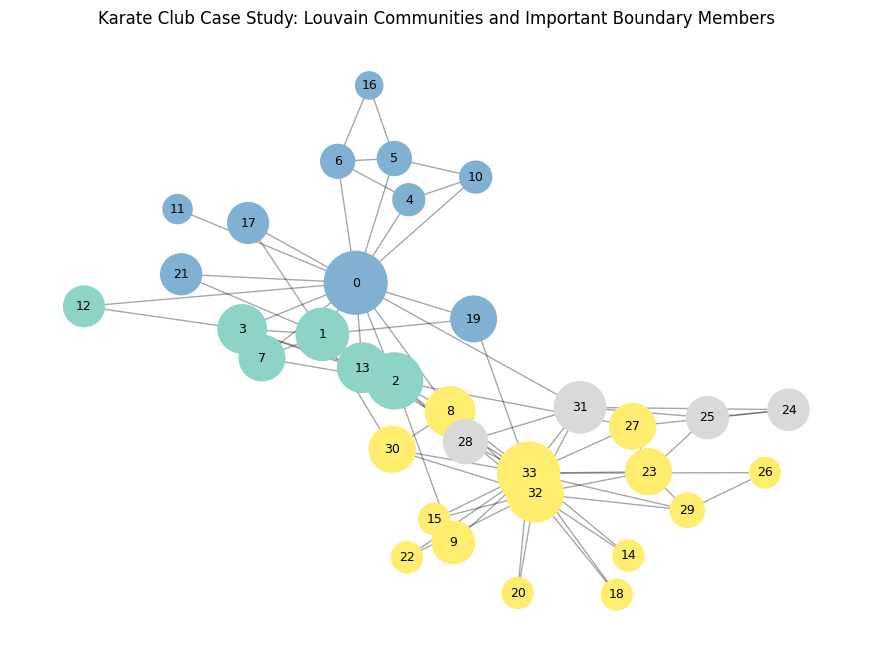

Figure exported to: exercise_11_outputs/karate_club_final_visualization.png


In [8]:
pos = nx.spring_layout(G, seed=42)

boundary_nodes = set(boundary_df["node"])

node_colors = [G.nodes[n]["louvain_community"] for n in G.nodes()]
node_sizes = []

for n in G.nodes():
    score = float(nodes_df.loc[nodes_df["node"] == n, "importance_score"].iloc[0])
    if n in boundary_nodes:
        node_sizes.append(700 + score * 1400)
    else:
        node_sizes.append(350 + score * 1200)

plt.figure(figsize=(11, 8))
nx.draw_networkx_edges(G, pos, alpha=0.35)
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    cmap=plt.cm.Set3
)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Karate Club Case Study: Louvain Communities and Important Boundary Members")
plt.axis("off")

figure_path = output_dir / "karate_club_final_visualization.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Figure exported to:", figure_path)

## 9. Export artifacts

This notebook exports at least two artifacts.  
Here we export four:

1. node importance table as CSV
2. graph file as GraphML
3. final metrics as TXT
4. final visualization as PNG


In [9]:
# 1. Node importance table
node_csv_path = output_dir / "karate_club_node_importance.csv"
ranked_nodes_df.to_csv(node_csv_path, index=False)

# 2. GraphML export with enriched attributes
graphml_path = output_dir / "karate_club_enriched.graphml"
nx.write_graphml(G, graphml_path)

# 3. Metrics text file
metrics_txt_path = output_dir / "karate_club_final_metrics.txt"
with open(metrics_txt_path, "w") as f:
    f.write("Karate Club Final Metrics\n")
    f.write("=========================\n")
    for key, value in metrics.items():
        f.write(f"{key}: {value}\n")

# 4. Known vs inferred split table
split_csv_path = output_dir / "karate_club_known_vs_louvain.csv"
known_vs_louvain.to_csv(split_csv_path)

print("Exported artifacts:")
print(node_csv_path)
print(graphml_path)
print(metrics_txt_path)
print(figure_path)
print(split_csv_path)

Exported artifacts:
exercise_11_outputs/karate_club_node_importance.csv
exercise_11_outputs/karate_club_enriched.graphml
exercise_11_outputs/karate_club_final_metrics.txt
exercise_11_outputs/karate_club_final_visualization.png
exercise_11_outputs/karate_club_known_vs_louvain.csv


## 10. Case-study summary

Zachary's Karate Club network shows how a small social network can already contain structural evidence of an internal split. The graph is connected but not dense, meaning that members are reachable through social paths even though not everyone is directly connected to everyone else. Centrality results show that nodes 0 and 33 are the dominant leaders, while nodes such as 2, 31, and 32 help connect different parts of the network. Louvain community detection finds communities that broadly correspond to the known `Mr. Hi` and `Officer` factions, although it also reveals smaller subgroups inside the larger split. Overall, the case study suggests that the club division was not random: the network structure already contained local circles, boundary members, and leadership positions that made the future split visible.
